In [7]:
!pip install -q ultralytics==8.3.198


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 65.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 6.0 MB/s eta 0:00:000:00:0100:01


In [1]:
# create_1000_subset.py
import random
import shutil
from pathlib import Path
import yaml
import sys

# ---------- USER CONFIG ----------
# Change these two paths as needed:
SOURCE_ROOT = Path("/kaggle/input/safetyy")   # <-- path to your full dataset root (where images + labels live)
OUT_ROOT    = Path("/kaggle/working/subsets/1000") # <-- path where the new subset will be created
# ----------------------------------

NUM_TOTAL = 1000
NUM_TRAIN = 700
NUM_VAL   = 200
NUM_TEST  = 100
RANDOM_SEED = 42
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def gather_labeled_images(src_root: Path):
    imgs = []
    for p in src_root.rglob("*"):
        if p.suffix.lower() in IMAGE_EXTS:
            label = p.with_suffix(".txt")
            # check same-folder label first
            if label.exists():
                imgs.append((p, label))
                continue
            # search for parallel labels/ folder pattern: <...>/labels/<stem>.txt
            found = list(src_root.rglob("labels/" + p.stem + ".txt"))
            if found:
                imgs.append((p, found[0]))
                continue
            # else skip images without labels
    return imgs

def make_dirs(out_root: Path):
    for sub in ["images/train", "images/val", "images/test", "labels/train", "labels/val", "labels/test"]:
        (out_root / sub).mkdir(parents=True, exist_ok=True)

def copy_pairs(pairs, img_dest: Path, lbl_dest: Path):
    for img_path, lbl_path in pairs:
        shutil.copy2(img_path, img_dest / img_path.name)
        shutil.copy2(lbl_path, lbl_dest / (img_path.stem + ".txt"))

def create_data_yaml(out_root: Path, nc: int, names: list):
    data = {
        "path": str(out_root),       # root used by ultralytics (so train/val are relative)
        "train": "images/train",
        "val": "images/val",
        "nc": nc,
        "names": names
    }
    with open(out_root / "data.yaml", "w") as f:
        yaml.dump(data, f, sort_keys=False)
    print("[INFO] Wrote data.yaml:", out_root / "data.yaml")

def detect_num_classes(label_files):
    max_cls = -1
    for f in label_files:
        for L in open(f, "r").read().splitlines():
            L = L.strip()
            if not L:
                continue
            try:
                cls = int(L.split()[0])
                if cls > max_cls:
                    max_cls = cls
            except:
                pass
    nc = (max_cls + 1) if max_cls >= 0 else 1
    names = [f"class{i}" for i in range(nc)]
    return nc, names

def main():
    if not SOURCE_ROOT.exists():
        print(f"[ERROR] SOURCE_ROOT does not exist: {SOURCE_ROOT}")
        sys.exit(1)

    all_pairs = gather_labeled_images(SOURCE_ROOT)
    print(f"[INFO] Found {len(all_pairs)} labeled images under {SOURCE_ROOT}")

    if len(all_pairs) < NUM_TOTAL:
        print(f"[ERROR] Not enough labeled images ({len(all_pairs)}) to sample {NUM_TOTAL}. Aborting.")
        sys.exit(1)

    random.seed(RANDOM_SEED)
    sampled = random.sample(all_pairs, NUM_TOTAL)

    train_pairs = sampled[:NUM_TRAIN]
    val_pairs   = sampled[NUM_TRAIN:NUM_TRAIN+NUM_VAL]
    test_pairs  = sampled[NUM_TRAIN+NUM_VAL:NUM_TRAIN+NUM_VAL+NUM_TEST]

    # create folders
    make_dirs(OUT_ROOT)

    # copy files
    copy_pairs(train_pairs, OUT_ROOT / "images/train", OUT_ROOT / "labels/train")
    copy_pairs(val_pairs,   OUT_ROOT / "images/val",   OUT_ROOT / "labels/val")
    copy_pairs(test_pairs,  OUT_ROOT / "images/test",  OUT_ROOT / "labels/test")

    print(f"[INFO] Copied: train={len(train_pairs)}, val={len(val_pairs)}, test={len(test_pairs)}")
    # write test list (optional)
    with open(OUT_ROOT / "test.txt", "w") as f:
        for img_path, _ in test_pairs:
            f.write(str(img_path.name) + "\n")
    print("[INFO] Wrote test.txt listing test image filenames.")

    # detect classes from labels inside new subset (labels copied)
    label_files = list((OUT_ROOT / "labels").rglob("*.txt"))
    nc, names = detect_num_classes(label_files)
    print(f"[INFO] Detected {nc} classes -> names will be {names[:5]}{'...' if len(names)>5 else ''}")

    create_data_yaml(OUT_ROOT, nc, names)
    print("[DONE] Subset created at:", OUT_ROOT)
    print("You can point your train.py at this folder (example):")
    print(f"  python train.py --dataset {OUT_ROOT} --epochs 40 --batch 8 --imgsz 640 --name subset_1000_run --augment")

if __name__ == "__main__":
    main()


[INFO] Found 7056 labeled images under /kaggle/input/safetyy
[INFO] Copied: train=700, val=200, test=100
[INFO] Wrote test.txt listing test image filenames.
[INFO] Detected 3 classes -> names will be ['class0', 'class1', 'class2']
[INFO] Wrote data.yaml: /kaggle/working/subsets/1000/data.yaml
[DONE] Subset created at: /kaggle/working/subsets/1000
You can point your train.py at this folder (example):
  python train.py --dataset /kaggle/working/subsets/1000 --epochs 40 --batch 8 --imgsz 640 --name subset_1000_run --augment


In [4]:
train_code = """
import os
import argparse
from pathlib import Path
from ultralytics import YOLO

def find_data_yaml(folder: Path):
    candidates = [
        folder / "data.yaml",
        folder / "data" / "data.yaml",
        folder / "dataset.yaml"
    ]
    for c in candidates:
        if c.exists():
            return str(c)
    found = list(folder.rglob("data.yaml"))
    if found:
        return str(found[0])
    return None

def parse_args():
    p = argparse.ArgumentParser(description="Flexible YOLOv8 training wrapper")
    p.add_argument("--dataset", type=str, default="data/processed")
    p.add_argument("--model", type=str, default="yolov8n.pt")
    p.add_argument("--epochs", type=int, default=50)
    p.add_argument("--batch", type=int, default=16)
    p.add_argument("--imgsz", type=int, default=640)
    p.add_argument("--lr", type=float, default=0.001)
    p.add_argument("--optimizer", type=str, default="AdamW", choices=["SGD","Adam","AdamW","RMSProp"])
    p.add_argument("--workers", type=int, default=4)
    p.add_argument("--name", type=str, default="yolov8_run")
    p.add_argument("--augment", action="store_true")
    p.add_argument("--device", type=str, default="", help="e.g. '0' or 'cpu'")
    p.add_argument("--resume", action="store_true")
    return p.parse_args()

def main():
    args = parse_args()
    dataset_folder = Path(args.dataset)
    if not dataset_folder.exists():
        print(f"[ERROR] dataset folder does not exist: {dataset_folder}")
        return
    data_yaml = find_data_yaml(dataset_folder)
    if data_yaml is None:
        print(f"[ERROR] Could not find data.yaml inside {dataset_folder}.")
        return
    print(f"[INFO] Using data config: {data_yaml}")
    print(f"[INFO] Model: {args.model}, epochs: {args.epochs}, batch: {args.batch}, imgsz: {args.imgsz}, lr: {args.lr}")
    model = YOLO(args.model)
    train_kwargs = dict(
        data=data_yaml,
        epochs=args.epochs,
        imgsz=args.imgsz,
        batch=args.batch,
        workers=args.workers,
        optimizer=args.optimizer,
        lr0=args.lr,
        name=args.name,
        augment=args.augment,
        device=args.device if args.device else None,
        resume=args.resume
    )
    train_kwargs = {k:v for k,v in train_kwargs.items() if v is not None and v != ""}
    print("[INFO] Training kwargs:", train_kwargs)
    print("Starting training...")
    results = model.train(**train_kwargs)
    try:
        save_dir = results.save_dir
    except Exception:
        save_dir = f"runs/train/{args.name}"
    print("Training finished!")
    print(f"Results/weights saved to: {save_dir}")

if __name__ == "__main__":
    main()
"""
with open("train.py", "w") as f:
    f.write(train_code)

print("✅ train.py created at /kaggle/working/train.py")


✅ train.py created at /kaggle/working/train.py


In [8]:
!python train.py \
  --dataset /kaggle/working/subsets/1000 \
  --model yolov8n.pt \
  --epochs 40 \
  --batch 8 \
  --imgsz 640 \
  --lr 0.001 \
  --name subset_1000_run \
  --augment


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[INFO] Using data config: /kaggle/working/subsets/1000/data.yaml
[INFO] Model: yolov8n.pt, epochs: 40, batch: 8, imgsz: 640, lr: 0.001
[INFO] Training kwargs: {'data': '/kaggle/working/subsets/1000/data.yaml', 'epochs': 40, 'imgsz': 640, 'batch': 8, 'workers': 4, 'optimizer': 'AdamW', 'lr0': 0.001, 'name': 'subset_1000_run', 'augment': True, 'resume': False}
Starting training...
Ultralytics 8.3.198 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_p

In [13]:
# Evaluate on test set (python)
from pathlib import Path
import yaml
from ultralytics import YOLO

SUBSET = Path("/kaggle/working/subsets/1000")   # your subset
RUN_DIR = Path("runs/detect/subset_1000_run")
WEIGHT = RUN_DIR / "weights" / "best.pt"       # best.pt was generated in your run

if not WEIGHT.exists():
    # fallback to last.pt
    last = sorted((RUN_DIR / "weights").glob("*.pt"), key=lambda p: p.stat().st_mtime)[-1]
    WEIGHT = last

print("Using weights:", WEIGHT)

# prepare a temp data yaml that uses images/test as val
temp_yaml = SUBSET / "data_for_test.yaml"
orig_yaml = SUBSET / "data.yaml"
if not orig_yaml.exists():
    raise FileNotFoundError(f"data.yaml not found at {orig_yaml}")

# load class names & nc from original data.yaml if present; else detect manually
with open(orig_yaml, "r") as f:
    orig = yaml.safe_load(f)

data_test = {
    "path": str(SUBSET),
    "train": "images/train",
    "val": "images/test",   # point val -> test images
    "nc": orig.get("nc",  orig.get("num_classes", 1)),
    "names": orig.get("names", None)
}
with open(temp_yaml, "w") as f:
    yaml.dump(data_test, f, sort_keys=False)
print("Wrote temporary test yaml:", temp_yaml)

# load model and run validation (this prints AP/mAP/precision/recall)
model = YOLO(str(WEIGHT))
print("\n=== Running validation on TEST set ===")
res = model.val(data=str(temp_yaml), imgsz=640, verbose=True)
print("\nValidation finished. The 'res' object contains returned metrics (if needed).")


Using weights: runs/detect/subset_1000_run/weights/best.pt
Wrote temporary test yaml: /kaggle/working/subsets/1000/data_for_test.yaml

=== Running validation on TEST set ===
Ultralytics 8.3.198 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1250.6±732.6 MB/s, size: 58.7 KB)
val: Scanning /kaggle/working/subsets/1000/labels/test... 100 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 1.2Kit/s 0.1s
val: New cache created: /kaggle/working/subsets/1000/labels/test.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 13, len(boxes) = 526. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        100        526      0.807      0.682      0.776      0.459
                class0         75        167      0.858      0.731       0.82      0.501
                class1         79        153      0.765       0.64      0.737      0.423
                class2         89        206      0.797      0.675       0.77      0.454
Speed: 2.5ms preprocess, 7.6ms inference, 0.0ms loss, 7.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

Validation finished. The 'res' object contains returned metrics (if needed).


Found 100 predicted images.

First 10 predicted images (full paths):
  /kaggle/working/runs/detect/predict/helmet_jacket_03502_jpg.rf.3cfad3b030d2a4ed53ca9b2629207e99.jpg
  /kaggle/working/runs/detect/predict/helmet_jacket_03503_jpg.rf.e2af6ac6e76a8c60ef852d93bc3da363.jpg
  /kaggle/working/runs/detect/predict/helmet_jacket_03517_jpg.rf.142ed87c945ec5800aa969a6dea51612.jpg
  /kaggle/working/runs/detect/predict/helmet_jacket_03535_jpg.rf.14840b91055806a5ef5e8de99b271c2d.jpg
  /kaggle/working/runs/detect/predict/helmet_jacket_03546_jpg.rf.cd9f58f7778f6320122ba507871bd2c5.jpg
  /kaggle/working/runs/detect/predict/helmet_jacket_03563_jpg.rf.052e4b581b66ef5d5acc0e7e317f806f.jpg
  /kaggle/working/runs/detect/predict/helmet_jacket_03617_jpg.rf.ff76eb4a87252e8f6e5881b55551d6b7.jpg
  /kaggle/working/runs/detect/predict/helmet_jacket_03741_jpg.rf.95225032cabb68a773e7c60db36c87b9.jpg
  /kaggle/working/runs/detect/predict/helmet_jacket_03745_jpg.rf.d87d73781c97aedec2662840a8424a3c.jpg
  /kaggle/wor

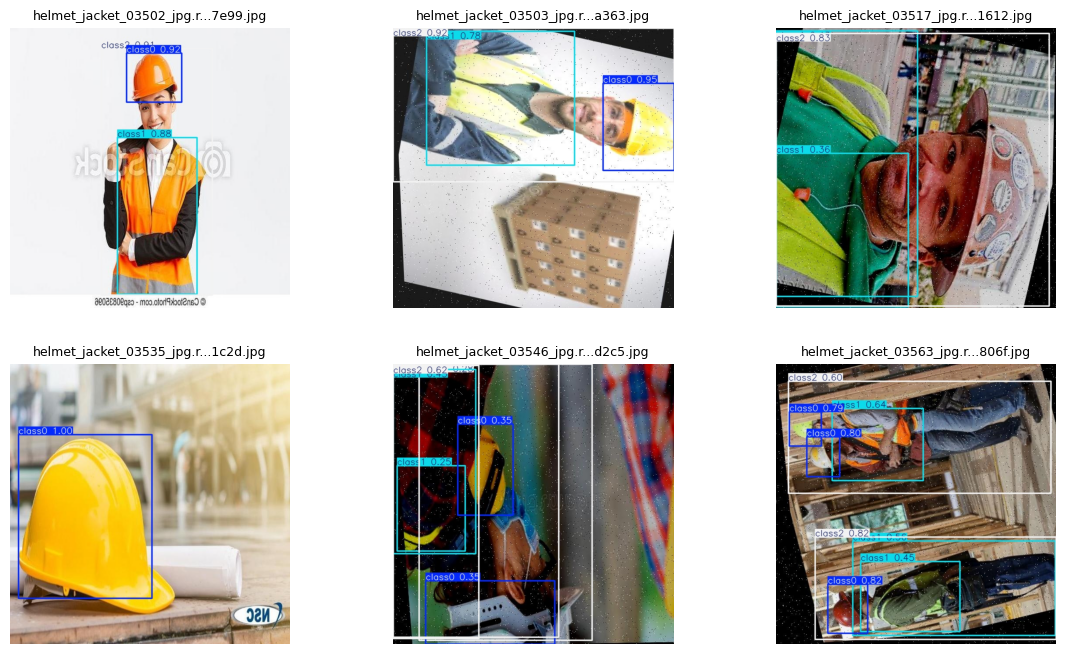

In [21]:
import glob
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

PRED_DIR = Path("/kaggle/working/runs/detect/predict")

# find annotated images
img_files = sorted(glob.glob(str(PRED_DIR/"*"))) + sorted(glob.glob(str(PRED_DIR/"*/*")))
img_files = [p for p in img_files if p.lower().endswith(('.jpg','.jpeg','.png'))]

print(f"Found {len(img_files)} predicted images.")
if img_files:
    # print the first 10 full filenames in console
    print("\nFirst 10 predicted images (full paths):")
    for p in img_files[:10]:
        print(" ", p)

    # show first 6 in a grid with shortened titles
    sample = img_files[:6]
    cols, rows = 3, (len(sample)+2)//3
    plt.figure(figsize=(14, 4*rows))
    for i,p in enumerate(sample):
        img = Image.open(p)
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis('off')
        fname = Path(p).name
        # shorten long names for display
        if len(fname) > 35:
            fname = fname[:25] + "..." + fname[-8:]
        plt.title(fname, fontsize=9)
    plt.show()
else:
    print("No predicted images found. Run model.predict(..., save=True) first.")


In [23]:
from pathlib import Path

fname = "helmet_jacket_03502_jpg.rf.3cfad3b030d2a4ed53ca9b2629207e99.txt"
txt_path = Path("/kaggle/working/runs/detect/predict/labels") / fname

if txt_path.exists():
    with open(txt_path) as f:
        lines = f.read().splitlines()
    print(f"File: {txt_path}, {len(lines)} detections")
    for line in lines[:10]:  # show first 10 detections
        print(line)
else:
    print("No prediction file found for", txt_path)


File: /kaggle/working/runs/detect/predict/labels/helmet_jacket_03502_jpg.rf.3cfad3b030d2a4ed53ca9b2629207e99.txt, 3 detections
0 0.514848 0.176859 0.196473 0.175401
2 0.524247 0.513999 0.397367 0.879098
1 0.526158 0.671456 0.284476 0.558974


In [25]:
ls -R /kaggle/working/runs/detect/subset_1000_run


/kaggle/working/runs/detect/subset_1000_run:
args.yaml                        results.csv          val_batch0_labels.jpg
BoxF1_curve.png                  results.png          val_batch0_pred.jpg
BoxP_curve.png                   train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png                  train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png                   train_batch2640.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch2641.jpg  val_batch2_pred.jpg
confusion_matrix.png             train_batch2642.jpg  weights/
labels.jpg                       train_batch2.jpg

/kaggle/working/runs/detect/subset_1000_run/weights:
best.pt  last.pt


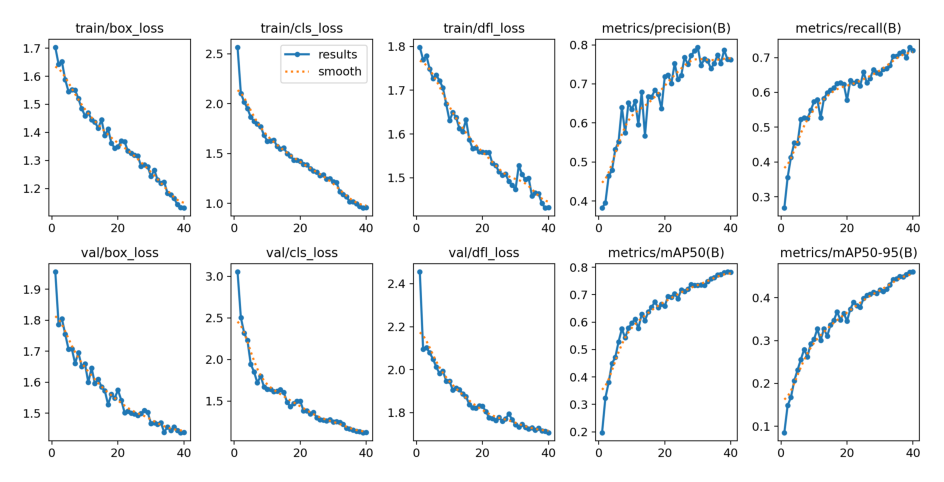

In [27]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/kaggle/working/runs/detect/subset_1000_run/results.png"
img = Image.open(img_path)
plt.figure(figsize=(12,6))
plt.imshow(img)
plt.axis('off')
plt.show()


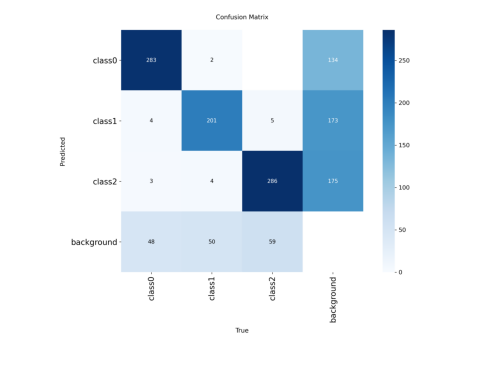

In [28]:
img_path = "/kaggle/working/runs/detect/subset_1000_run/confusion_matrix.png"
img = Image.open(img_path)
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.show()


In [ ]:
!python train.py \
  --dataset /kaggle/working/subsets/1000 \
  --model yolov8n.pt \
  --epochs 40 \
  --batch 8 \
  --imgsz 640 \
  --lr 0.001 \
  --optimizer AdamW \
  --name  optadamw \
  --augment


In [32]:
!python train.py \
  --dataset /kaggle/working/subsets/1000 \
  --model yolov8n.pt \
  --epochs 50 \
  --batch 8 \
  --imgsz 640 \
  --lr 0.001 \
  --optimizer AdamW \
  --name  epoch50 \
  --augment


[INFO] Using data config: /kaggle/working/subsets/1000/data.yaml
[INFO] Model: yolov8n.pt, epochs: 50, batch: 8, imgsz: 640, lr: 0.001
[INFO] Training kwargs: {'data': '/kaggle/working/subsets/1000/data.yaml', 'epochs': 50, 'imgsz': 640, 'batch': 8, 'workers': 4, 'optimizer': 'AdamW', 'lr0': 0.001, 'name': 'epoch50', 'augment': True, 'resume': False}
Starting training...
Ultralytics 8.3.198 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/subsets/1000/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv

Columns in results.csv: Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


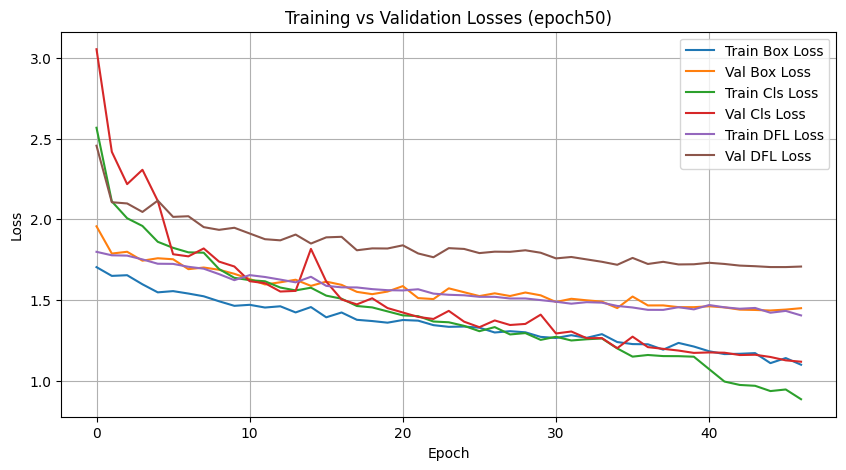

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# pick which run you want to plot
run_name = "epoch50"   # change this to your run folder name
csv_path = Path(f"/kaggle/working/runs/detect/{run_name}/results.csv")

# load CSV
df = pd.read_csv(csv_path)
print("Columns in results.csv:", df.columns)

# Plot training and validation losses
plt.figure(figsize=(10,5))
plt.plot(df.index, df['train/box_loss'], label='Train Box Loss')
plt.plot(df.index, df['val/box_loss'], label='Val Box Loss')

# If classification loss and distribution focal loss exist, plot them too
if 'train/cls_loss' in df and 'val/cls_loss' in df:
    plt.plot(df.index, df['train/cls_loss'], label='Train Cls Loss')
    plt.plot(df.index, df['val/cls_loss'], label='Val Cls Loss')
if 'train/dfl_loss' in df and 'val/dfl_loss' in df:
    plt.plot(df.index, df['train/dfl_loss'], label='Train DFL Loss')
    plt.plot(df.index, df['val/dfl_loss'], label='Val DFL Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training vs Validation Losses ({run_name})")
plt.legend()
plt.grid(True)
plt.show()

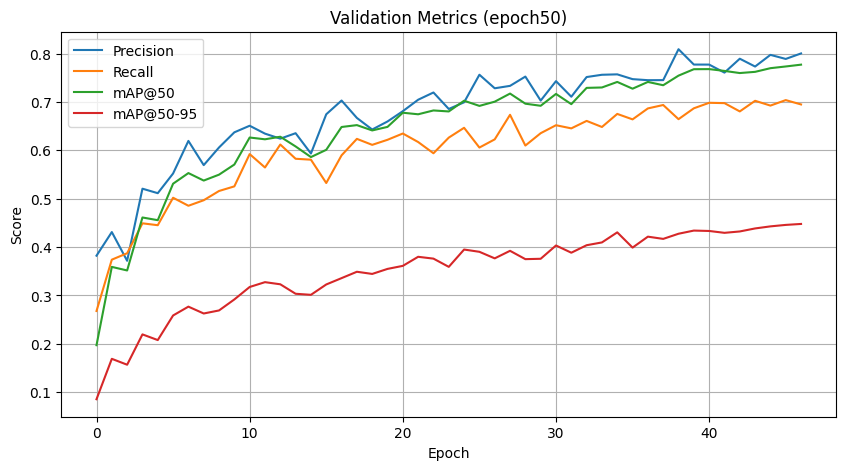

In [38]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['metrics/precision(B)'], label='Precision')
plt.plot(df.index, df['metrics/recall(B)'], label='Recall')
plt.plot(df.index, df['metrics/mAP50(B)'], label='mAP@50')
plt.plot(df.index, df['metrics/mAP50-95(B)'], label='mAP@50-95')

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title(f"Validation Metrics ({run_name})")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
!python train.py \
  --dataset /kaggle/working/subsets/1000 \
  --model yolov8n.pt \
  --epochs 80 \
  --batch 8 \
  --imgsz 640 \
  --lr 0.005 \
  --optimizer AdamW \
  --name  epoche80 \
  --augment


[INFO] Using data config: /kaggle/working/subsets/1000/data.yaml
[INFO] Model: yolov8n.pt, epochs: 80, batch: 8, imgsz: 640, lr: 0.005
[INFO] Training kwargs: {'data': '/kaggle/working/subsets/1000/data.yaml', 'epochs': 80, 'imgsz': 640, 'batch': 8, 'workers': 4, 'optimizer': 'AdamW', 'lr0': 0.005, 'name': 'epoche80', 'augment': True, 'resume': False}
Starting training...
Ultralytics 8.3.198 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/subsets/1000/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hs

Columns in results.csv: Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


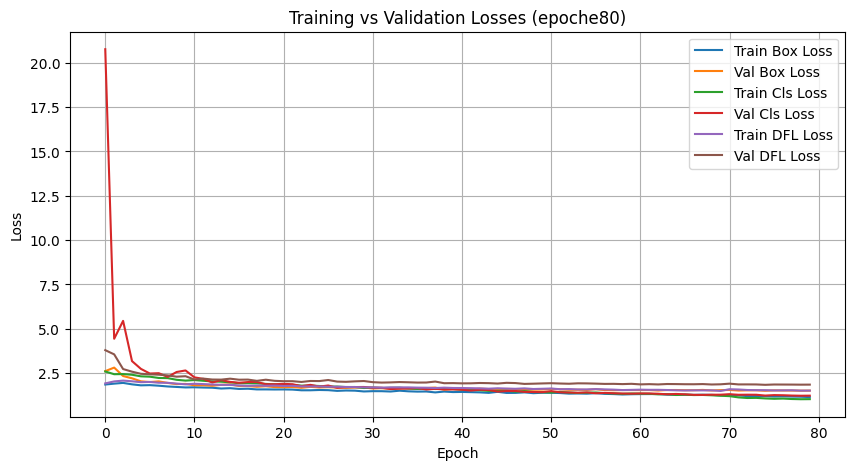

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# pick which run you want to plot
run_name = "epoche80"   # change this to your run folder name
csv_path = Path(f"/kaggle/working/runs/detect/{run_name}/results.csv")

# load CSV
df = pd.read_csv(csv_path)
print("Columns in results.csv:", df.columns)

# Plot training and validation losses
plt.figure(figsize=(10,5))
plt.plot(df.index, df['train/box_loss'], label='Train Box Loss')
plt.plot(df.index, df['val/box_loss'], label='Val Box Loss')

# If classification loss and distribution focal loss exist, plot them too
if 'train/cls_loss' in df and 'val/cls_loss' in df:
    plt.plot(df.index, df['train/cls_loss'], label='Train Cls Loss')
    plt.plot(df.index, df['val/cls_loss'], label='Val Cls Loss')
if 'train/dfl_loss' in df and 'val/dfl_loss' in df:
    plt.plot(df.index, df['train/dfl_loss'], label='Train DFL Loss')
    plt.plot(df.index, df['val/dfl_loss'], label='Val DFL Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training vs Validation Losses ({run_name})")
plt.legend()
plt.grid(True)
plt.show()


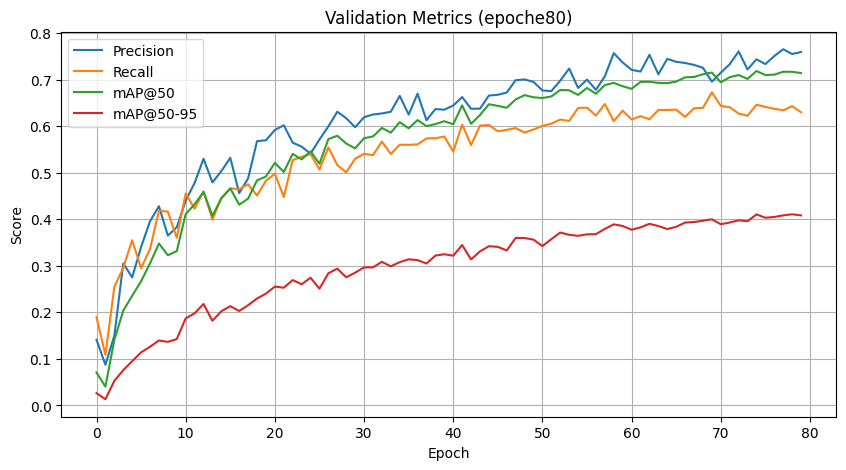

In [35]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['metrics/precision(B)'], label='Precision')
plt.plot(df.index, df['metrics/recall(B)'], label='Recall')
plt.plot(df.index, df['metrics/mAP50(B)'], label='mAP@50')
plt.plot(df.index, df['metrics/mAP50-95(B)'], label='mAP@50-95')

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title(f"Validation Metrics ({run_name})")
plt.legend()
plt.grid(True)
plt.show()


In [39]:
!python train.py \
  --dataset /kaggle/working/subsets/1000 \
  --model yolov8s.pt \
  --epochs 50 \
  --batch 16 \
  --imgsz 640 \
  --lr 0.0008 \
  --optimizer AdamW \
  --name  epochs50/0.0008 \
  --augment


[INFO] Using data config: /kaggle/working/subsets/1000/data.yaml
[INFO] Model: yolov8s.pt, epochs: 50, batch: 16, imgsz: 640, lr: 0.0008
[INFO] Training kwargs: {'data': '/kaggle/working/subsets/1000/data.yaml', 'epochs': 50, 'imgsz': 640, 'batch': 16, 'workers': 4, 'optimizer': 'AdamW', 'lr0': 0.0008, 'name': 'epochs50/0.0008', 'augment': True, 'resume': False}
Starting training...
Ultralytics 8.3.198 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/subsets/1000/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, ha

Columns in results.csv: Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


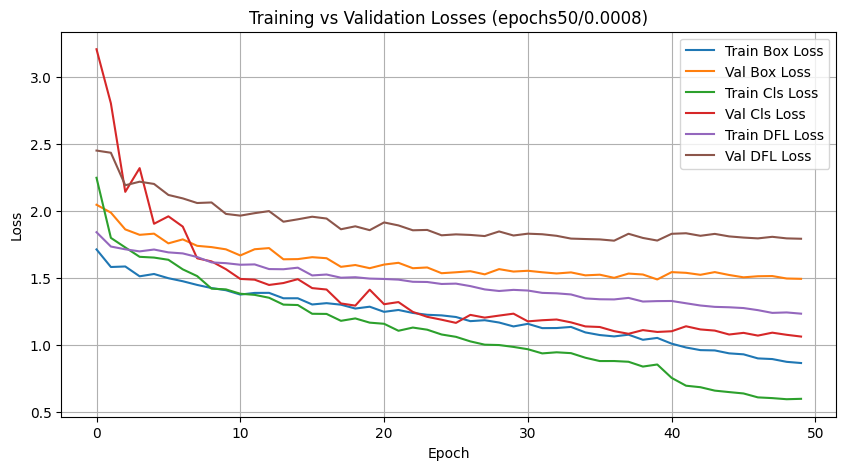

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# pick which run you want to plot
run_name = "epochs50/0.0008"   # change this to your run folder name
csv_path = Path(f"/kaggle/working/runs/detect/{run_name}/results.csv")

# load CSV
df = pd.read_csv(csv_path)
print("Columns in results.csv:", df.columns)

# Plot training and validation losses
plt.figure(figsize=(10,5))
plt.plot(df.index, df['train/box_loss'], label='Train Box Loss')
plt.plot(df.index, df['val/box_loss'], label='Val Box Loss')

# If classification loss and distribution focal loss exist, plot them too
if 'train/cls_loss' in df and 'val/cls_loss' in df:
    plt.plot(df.index, df['train/cls_loss'], label='Train Cls Loss')
    plt.plot(df.index, df['val/cls_loss'], label='Val Cls Loss')
if 'train/dfl_loss' in df and 'val/dfl_loss' in df:
    plt.plot(df.index, df['train/dfl_loss'], label='Train DFL Loss')
    plt.plot(df.index, df['val/dfl_loss'], label='Val DFL Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training vs Validation Losses ({run_name})")
plt.legend()
plt.grid(True)
plt.show()

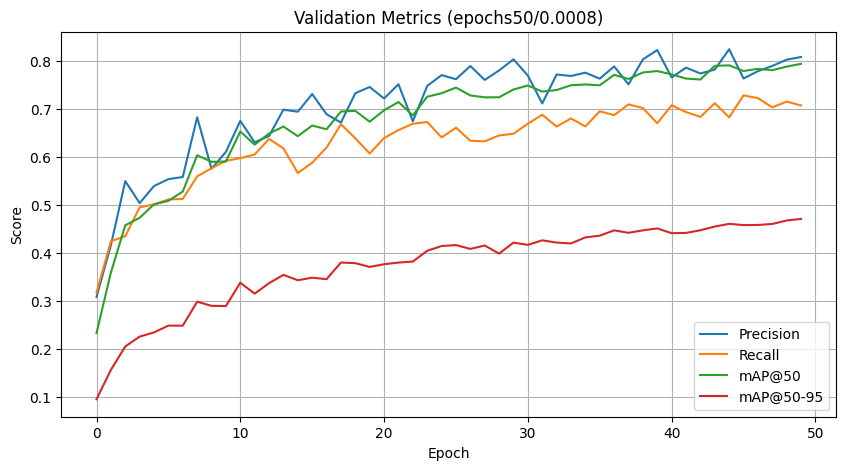

In [41]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['metrics/precision(B)'], label='Precision')
plt.plot(df.index, df['metrics/recall(B)'], label='Recall')
plt.plot(df.index, df['metrics/mAP50(B)'], label='mAP@50')
plt.plot(df.index, df['metrics/mAP50-95(B)'], label='mAP@50-95')

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title(f"Validation Metrics ({run_name})")
plt.legend()
plt.grid(True)
plt.show()


In [42]:
!python train.py \
  --dataset /kaggle/working/subsets/1000 \
  --model yolov8s.pt \
  --epochs 100 \
  --batch 16 \
  --imgsz 640 \
  --lr 0.0008 \
  --optimizer AdamW \
  --patience 20 \
  --name epo100/batch16 \
  --augment


usage: train.py [-h] [--dataset DATASET] [--model MODEL] [--epochs EPOCHS]
                [--batch BATCH] [--imgsz IMGSZ] [--lr LR]
                [--optimizer {SGD,Adam,AdamW,RMSProp}] [--workers WORKERS]
                [--name NAME] [--augment] [--device DEVICE] [--resume]
train.py: error: unrecognized arguments: --patience 20


In [ ]:
import os
import argparse
from pathlib import Path
from ultralytics import YOLO

def find_data_yaml(folder: Path):
    candidates = [
        folder / "data.yaml",
        folder / "data" / "data.yaml",
        folder / "dataset.yaml"
    ]
    for c in candidates:
        if c.exists():
            return str(c)
    found = list(folder.rglob("data.yaml"))
    if found:
        return str(found[0])
    return None

def parse_args():
    p = argparse.ArgumentParser(description="Flexible YOLOv8 training wrapper")
    p.add_argument("--dataset", type=str, default="data/processed")
    p.add_argument("--model", type=str, default="yolov8n.pt")
    p.add_argument("--epochs", type=int, default=50)
    p.add_argument("--batch", type=int, default=16)
    p.add_argument("--imgsz", type=int, default=640)
    p.add_argument("--lr", type=float, default=0.001)
    p.add_argument("--optimizer", type=str, default="AdamW", choices=["SGD","Adam","AdamW","RMSProp"])
    p.add_argument("--workers", type=int, default=4)
    p.add_argument("--name", type=str, default="yolov8_run")
    p.add_argument("--augment", action="store_true")
    p.add_argument("--device", type=str, default="", help="e.g. '0' or 'cpu'")
    p.add_argument("--resume", action="store_true")
    p.add_argument("--patience", type=int, default=None, help="Early stopping patience (epochs)")
    return p.parse_args()

def main():
    args = parse_args()
    dataset_folder = Path(args.dataset)
    if not dataset_folder.exists():
        print(f"[ERROR] dataset folder does not exist: {dataset_folder}")
        return
    data_yaml = find_data_yaml(dataset_folder)
    if data_yaml is None:
        print(f"[ERROR] Could not find data.yaml inside {dataset_folder}.")
        return

    print(f"[INFO] Using data config: {data_yaml}")
    print(f"[INFO] Model: {args.model}, epochs: {args.epochs}, batch: {args.batch}, imgsz: {args.imgsz}, lr: {args.lr}")
    model = YOLO(args.model)

    train_kwargs = dict(
        data=data_yaml,
        epochs=args.epochs,
        imgsz=args.imgsz,
        batch=args.batch,
        workers=args.workers,
        optimizer=args.optimizer,
        lr0=args.lr,
        name=args.name,
        augment=args.augment,
        device=args.device if args.device else None,
        resume=args.resume,
        patience=args.patience   # ✅ added here
    )

    # filter None/empty values
    train_kwargs = {k:v for k,v in train_kwargs.items() if v is not None and v != ""}

    print("[INFO] Training kwargs:", train_kwargs)
    print("Starting training...")
    results = model.train(**train_kwargs)
    try:
        save_dir = results.save_dir
    except Exception:
        save_dir = f"runs/train/{args.name}"
    print("Training finished!")
    print(f"Results/weights saved to: {save_dir}")

if __name__ == "__main__":
    main()


In [ ]:
from ultralytics import YOLO
from PIL import Image
import os

def main():
    # --- Configuration ---
    MODEL_PATH = r'runs\detect\yolov8n_ppe_gpu_run_12\weights\best.pt'
    IMAGE_PATH = 'test_images/test_image.jpg'  
    

    CONFIDENCE_THRESHOLD = 0.65 
    # --- End of Configuration ---

    if not os.path.exists(MODEL_PATH) or not os.path.exists(IMAGE_PATH):
        print("Error: Model or image file not found. Please check paths.")
        return

    model = YOLO(MODEL_PATH)
    results = model(IMAGE_PATH)

    # --- Rule Engine Logic ---
    hardhat_detected = False
    vest_detected = False
    class_names = model.names
    
    for r in results:
        for box in r.boxes:
      
            confidence = float(box.conf[0])
            
            # --- APPLY THE THRESHOLD ---
            if confidence > CONFIDENCE_THRESHOLD:
                class_id = int(box.cls[0])
                class_name = class_names[class_id]
                
                if class_name == 'hardhat':
                    hardhat_detected = True
                elif class_name == 'vest':
                    vest_detected = True

    # --- Print Compliance Summary to Terminal ---
    print("\n--- Safety Compliance Check ---")
    if hardhat_detected:
        print(f"✅ Hardhat Status: [COMPLIANT] - Hardhat detected.")
    else:
        print(f"❌ Hardhat Status: [VIOLATION] - No hardhat detected (or confidence too low).")
        
    if vest_detected:
        print(f"✅ Vest Status:    [COMPLIANT] - Vest detected.")
    else:
        print(f"❌ Vest Status:    [VIOLATION] - No vest detected (or confidence too low).")
    
    print("---------------------------------\n")

    # --- Visualization ---
    for r in results:
        im_array = r.plot()
        im = Image.fromarray(im_array[..., ::-1])
        im.save('prediction_result.jpg')
    print("Result image saved to 'prediction_result.jpg'")


if __name__ == '__main__':
    main()